In [1]:
import amsterdm
from amsterdm.burst import Burst
import amsterdm.core
import amsterdm.plot as dmplot
from amsterdm.structure import Structure

Read the data.
Note the warning: missing header keys happen for actual data, but sometimes, these can easily be inferred, as here. Hence this is only a warning, not an actual error.

In [2]:
burst = Burst.fromfile("../amsterdm-sim.fits")

/Users/evert/projects/hessels2025/code/amsterdm/src/amsterdm/burst.py:94: UserWarning: 'nchans' not found in header; determining from the data
  warnings.warn("'nchans' not found in header; determining from the data")


For the data, at the moment the assumed order of dimensions is always (samples, polarization, frequency). If the data is two-dimensional, the polarization channel dimension is assumed to be 1.

In [3]:
burst.data.ndim

3

The data is converted to Stokes IQUV (or kept at plain Stokes I if there was only one polarization channel); the input data polarization type is determined from the header by checking for an appropriate keyword; here, this is "POLCHAN".

If the original data were different, it can't be accessed through the Burst class, and it can only be accessed from the original FITS file. This is done because all methods below are intended to work with Stokes I data.

There is an option to keep the original data intact (using `convert=False` in the `fromfile` method), but methods below may not work, or work incorrectly.

The `poltype` attribute of the burst tells the polarization of the converted data, while `orig_poltype` contains the original polarization ('xy' is the AmsterDM shortcut for XX-YY).

In [4]:
burst.poltype, burst.orig_poltype

('iquv', 'xy')

The header is largely kept as-is, and is obtained from the FITS file. Some keywords are inferred if they are missing; if an essential keyword is not found and can't be inferred, a `ValueError` would would be raised instead. E.g., 'nchans' has been added to the header; it is not in the actual FITS file, but can be deduced from the data shape.

Note that the "POLCHAN" keyword is left as is; use the `.poltype` as above to determine the actual polarization type of the data.

The header itself is a FITS header. At the moment, this is only the case for data read in from a FITS file. If the input is a Filterbank file, the data will be a Python `dict`, and comments at the end of each FITS line (card) are missing. Otherwise, both styles of headers behave the same, as a basic dictionary in Python. 

In [5]:
burst.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  128                                                  
NAXIS2  =                    4                                                  
NAXIS3  =                20000                                                  
OBJECT  = 'N/A     '           / source name                                    
SRCNAME = 'N/A     '           / source name                                    
COH_DM  =               123.45 / coherent dispersion measure                    
FCHAN1  =                 1400 / frequency of channel 1 [MHz]                   
FOFF    =                   -2 / frequency width of a channel                   
FANCHOR = 'mid     '           / anchor point on channel (top, bottom, mid)     
BADCHAN = '' / comma-separat

# Initial inspection and plotting of data

Create a first waterfall plot with a disperson measure (DM) of 0, a background section of 0 – 0.333 and 0.666 – 1 (see `amsterdm.constants`) and no bad channels.
Since the median is used by default in calculating the background (and therefore the bandpass), having part of the background overlap with the actual burst is unlikely to cause problems, and may still provide a good estimate of the background.

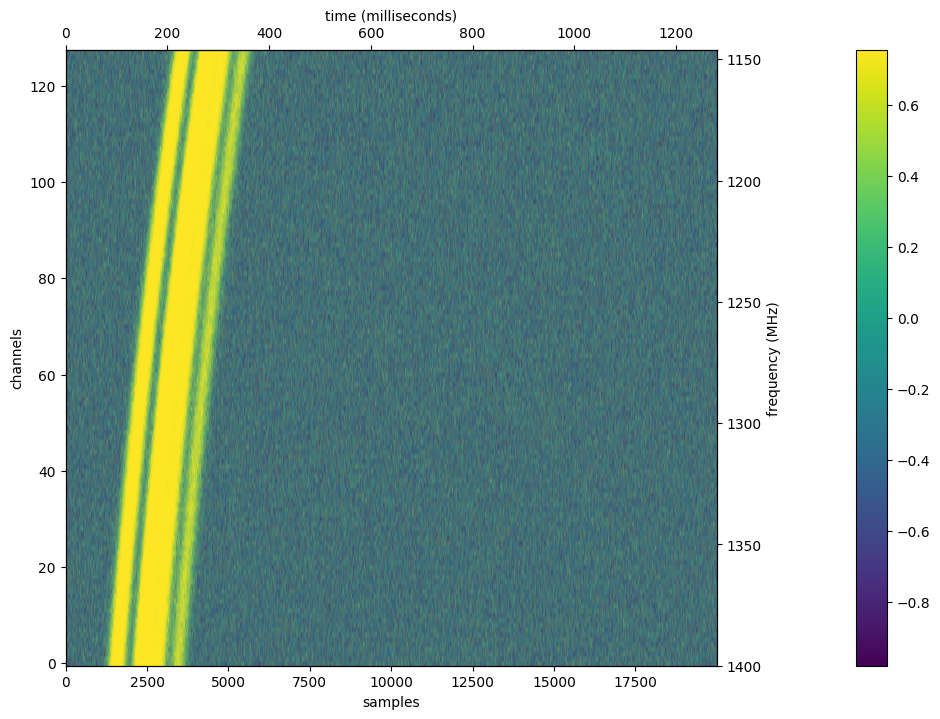

In [6]:
burst.waterfall(dm=0);

We can trim the data to remove the first part and a section of the latter part. Trimming will adjust the 'nsamples' header keyword, but it will not adjust 'tstart'.

Data is trimmed in-place; they only way to reset the data to its original is to reread the data from file, or create a deepcopy of the `burst` variable (there is as of yet no copy method built-in to the 'Burst' class).

In [7]:
burst.trim(samples=[0, 12_000])

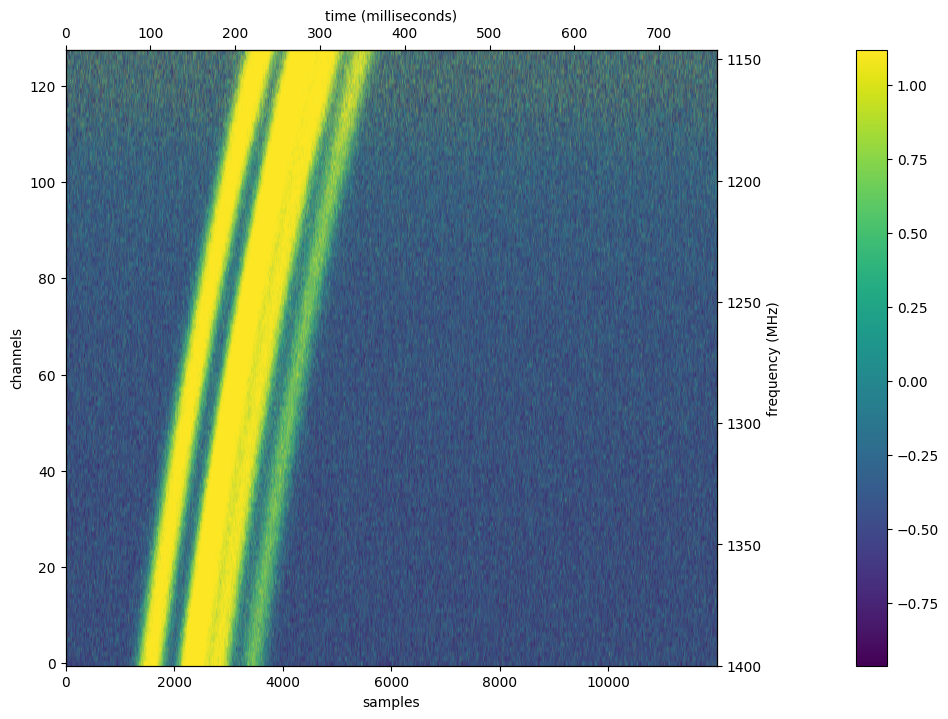

In [8]:
burst.waterfall(dm=0);

Now correct for the (correct) dispersion measure, flag some channels and set the background range to use only the right part of the dynamical spectrum to calculate the background value (note: dedispersion is done first, before the background calculation; this means that pixels from the left of the burst get rotated onto the right of the full spectrum).

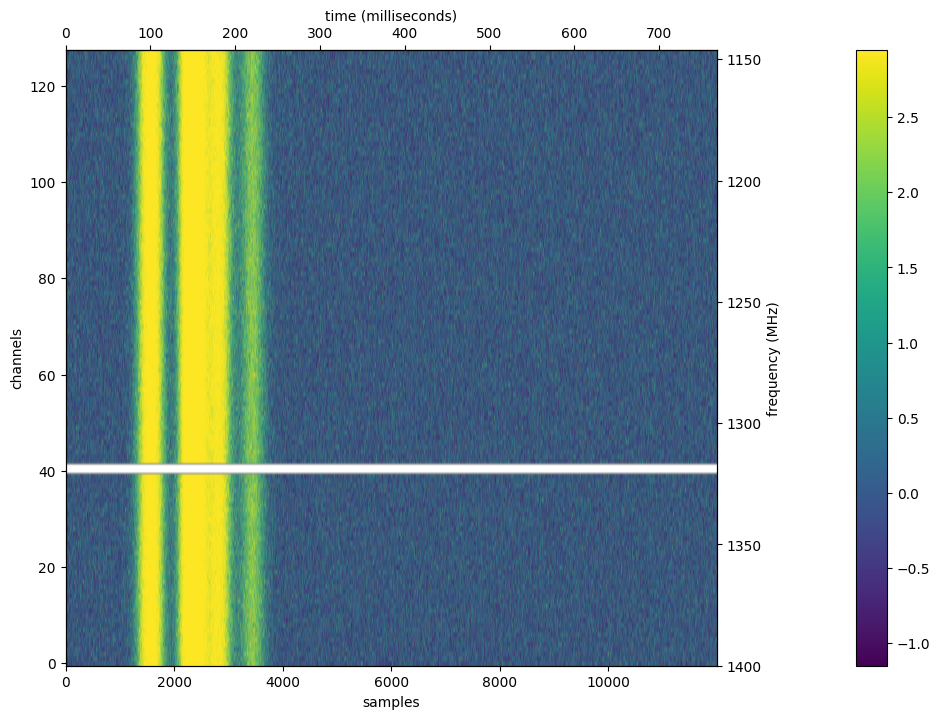

In [9]:
burst.waterfall(dm=123.45, badchannels=[40, 41], backgroundrange=[0.5, 1]);

Next, we can create a light curve plot

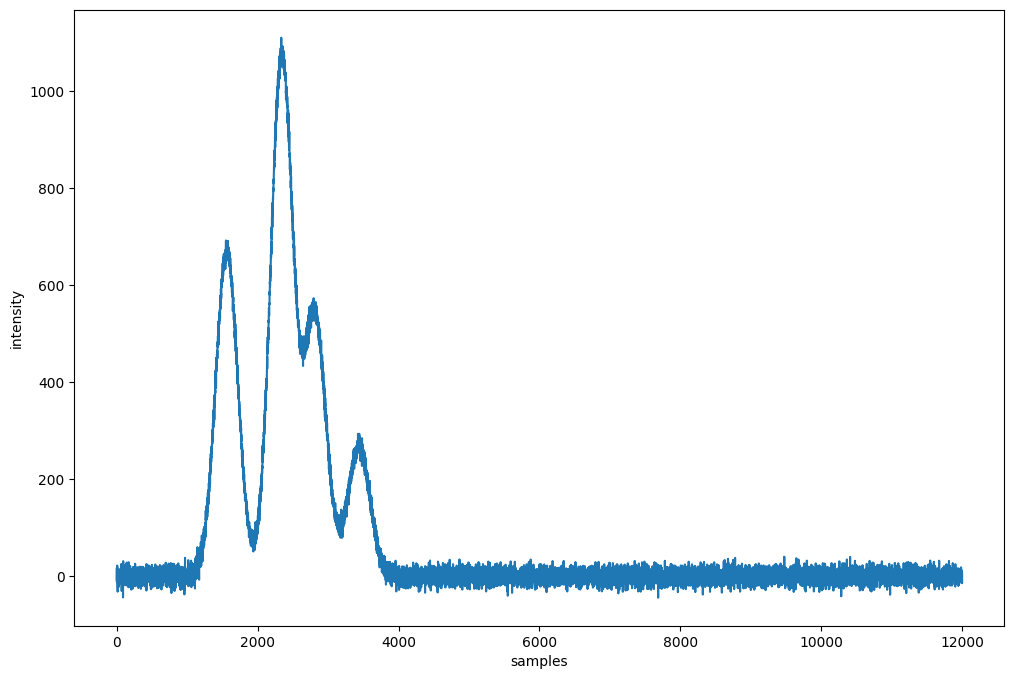

In [10]:
burst.lcplot(dm=123.45, badchannels=[40, 41], backgroundrange=[0.5, 1]);

If you want just the lightcurve data itself, call the `lightcurve` method:

In [11]:
lcdata = burst.lightcurve(dm=123.45, badchannels=[40, 41], backgroundrange=[0.7, 1])
lcdata

masked_array(data=[14.492568814929772, -1.8269617962999685,
                   -10.705311731648994, ..., -3.6107122013567885,
                   -14.277479247347216, 4.998486947028299],
             mask=[False, False, False, ..., False, False, False],
       fill_value=1e+20)

Note that these data are masked. This is because of the use of bad channels, even if these would be filtered out for a light curve. In this case, the mask is likely `False` everywhere:

In [12]:
np.any(lcdata.mask)

np.False_

We can now plot it with our set of plotting parameters if we'd like.

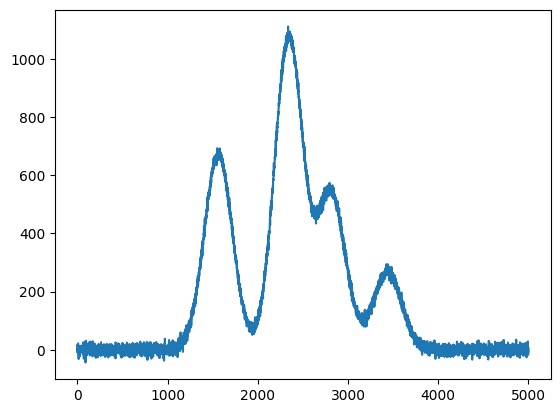

In [13]:
plt.plot(lcdata[:5_000]);

We can set the y-scale to logarithmic. In that case, all values at or below 0 would be invalid, and the plotting routine uses a trick to plot negative values, similarly to Matplotlib's [symlog scale](https://matplotlib.org/stable/gallery/scales/symlog_demo.html). The utility can be found in `amsterdm.utils.symlog`. Alternatively, you can set a lower cutoff for the y-scale, as is done in the example below. 
Note that the y-axis is not actually plotted with a logaritmic scale

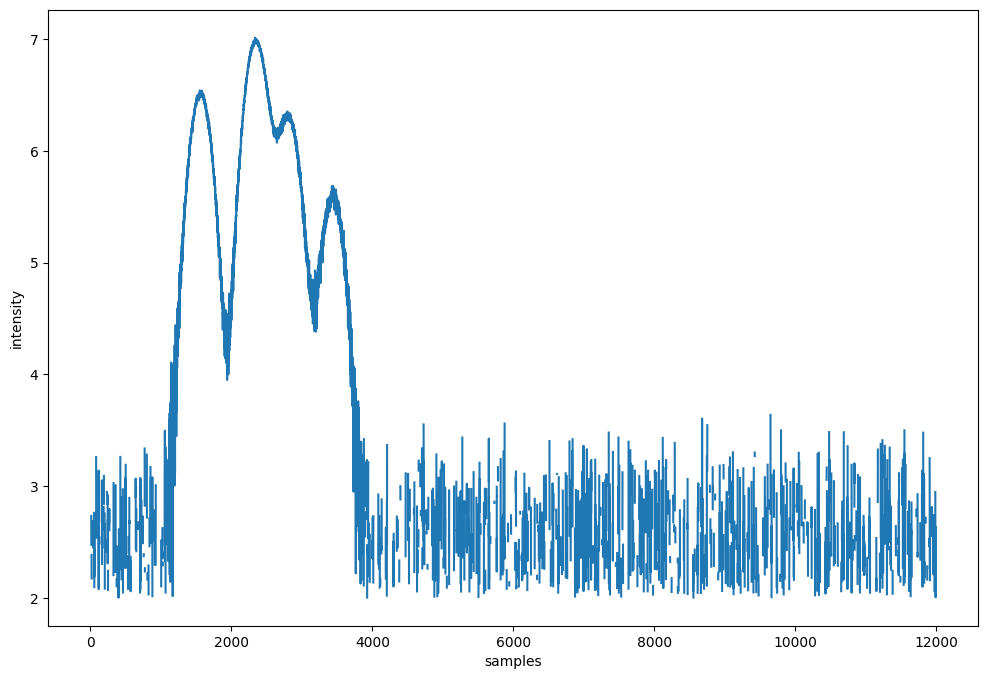

In [14]:
burst.lcplot(dm=123.45, badchannels=[40, 41], backgroundrange=[0.5, 1], logscale=True, ymin=2);

For further examples, let's set some variables.

In [15]:
DM = 123.45
badchannels = [40, 41]
bkgrange = [0.5, 1]

To view how well the background was estimated (for the bandpass correction), you can plot the background level together with the background standard deviation.
In this example, since it is simulated data, the background is really well behaved. Note the gap where two channels have been flagged.

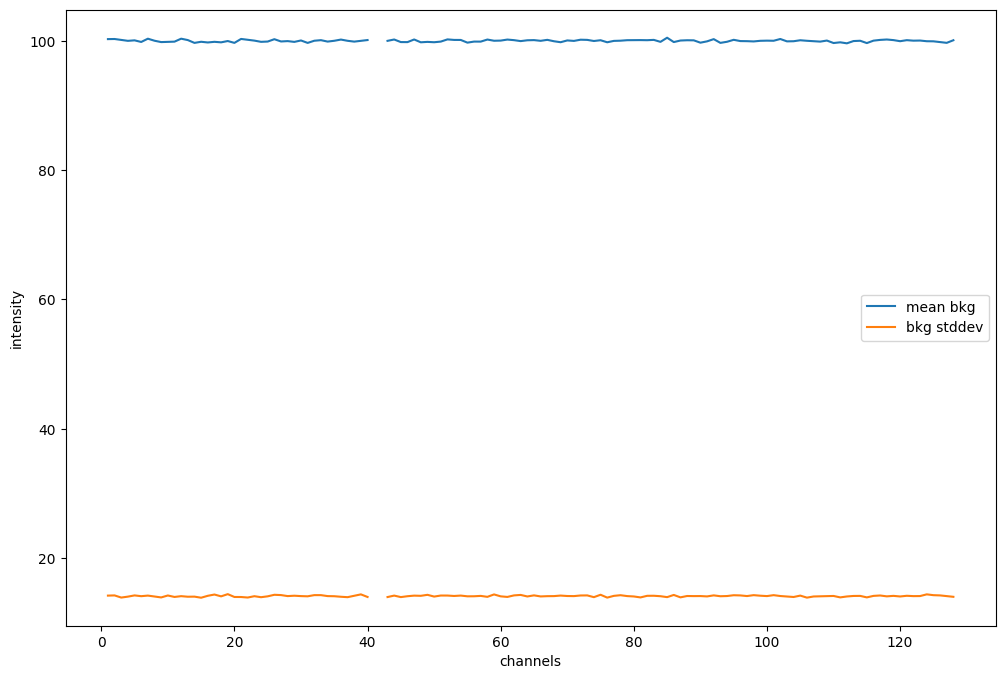

In [16]:
burst.bgplot(dm=DM, badchannels=badchannels, backgroundrange=bkgrange);

A signal-to-noise ratio plot can also be created. Here the sample-section of interest (which contains just the light curve) can be given with the `peak_interval` keyword argument: this should be a 2-element tuple of fraction of the total light curve.
If an interval is given, the background can still be calculated from other areas of the total sample range: the interval is mainly to speed up the calculation of the signal-to-noise.
By default, the maximum (peak) is used for the ratio; setting the `peak` keyword argument to `False` will use the full integrated light curve for the relevant interval (which is unlikely to change with changing DM).
Finally, a `dms` (dispersion measures) argument is an array of DMs to calculate the ratios for.

(<Figure size 1200x800 with 1 Axes>, <Axes: xlabel='DM', ylabel='S / N'>)

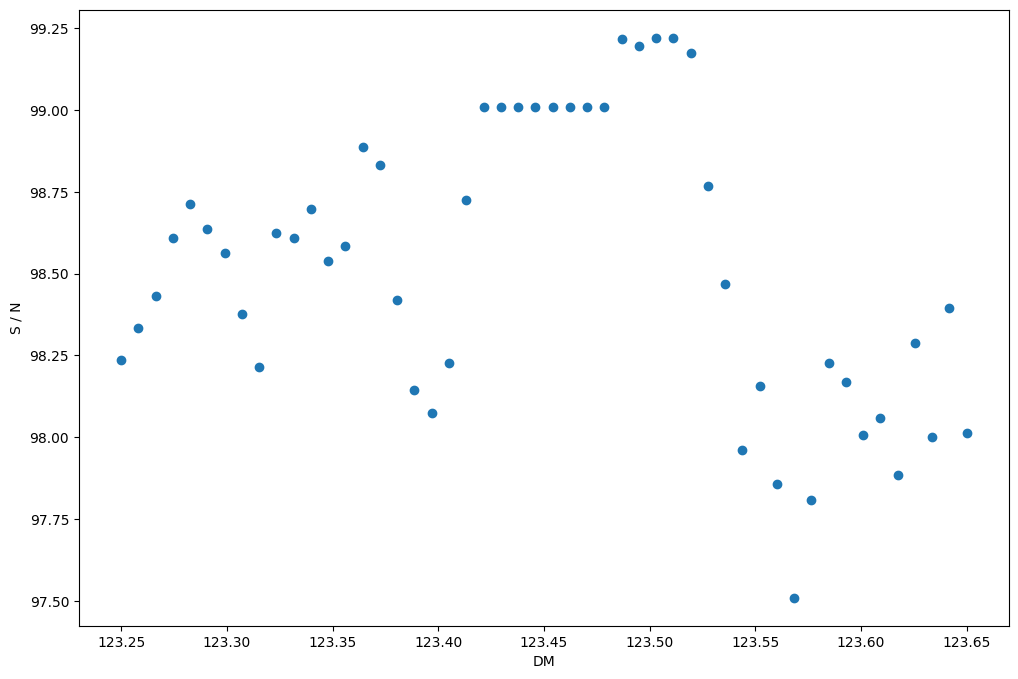

In [17]:
burst.s2nplot([DM-0.2, DM+0.2], ndm=50, badchannels=badchannels, backgroundrange=bkgrange, peak_interval=[0, 0.25])

Very bright bursts tend to show this flattening near the peak; it's an indication that the effective time resolution is not enough, and dedispersion by a small amount results in no actual change in the dynamical spectrum, since the shift is less than pixel width.

There is a little utility function that can try to find the sample section of the light curve automatically. The input of this utility is the actual light cruve data. To obtain that, we'll need to do some handwork, since there is not yet a method to derive the light curve data directly from a `Burst` instance. 

In [18]:
# Grab relevant information for dedispersion from the burst; `burst.freqs` is a convenience property
dm = {'dm': DM, 'freq': burst.freqs, 'tsamp': burst.header['tsamp']}
#lc = amsterdm.core.calc_lightcurve(burst.data, dm=dm, badchannels=badchannels, backgroundrange=bkgrange)
lc = burst.lightcurve(dm=DM, badchannels=badchannels, backgroundrange=bkgrange)
lc.shape

(12000,)

`lc` is a one-dimensional array with the light curve data; the sample axis is simply a linearly increasing array (`np.arange(len(lc))`), and if you want the time stamps instead, you can use `burst.times` which is convenience property.

To find the light curve section, use `amsterdm.core.findrangelc`. The algorithm is described in its docstring.
It returns a list of intervals where it finds an active light curve (overlapping sections being merged into one section). Since the light curve has no background gaps in this example, it finds one single section.
Note that the algorithm works well for brighter burst; it has not been tested on faint bursts.

In [19]:
sections = amsterdm.core.findrangelc(lc)
sections

([(np.int64(1117), np.int64(3814))],
 (np.float64(-18.588451427290536), np.float64(9.33453376415056)))

The sample range 1171 – 3762 agrees well with the light curve plot above.

The second pair of numbers is the estimated background value and standard deviation; so the actual background appears to be about one standard deviation below zero.

We can also plot a simple bowtie plot. Here, the input is a bit different: the dm is given as a range, with `ndm` a keyword argument on how many values to split the range into (we let it use its default of 50 here).

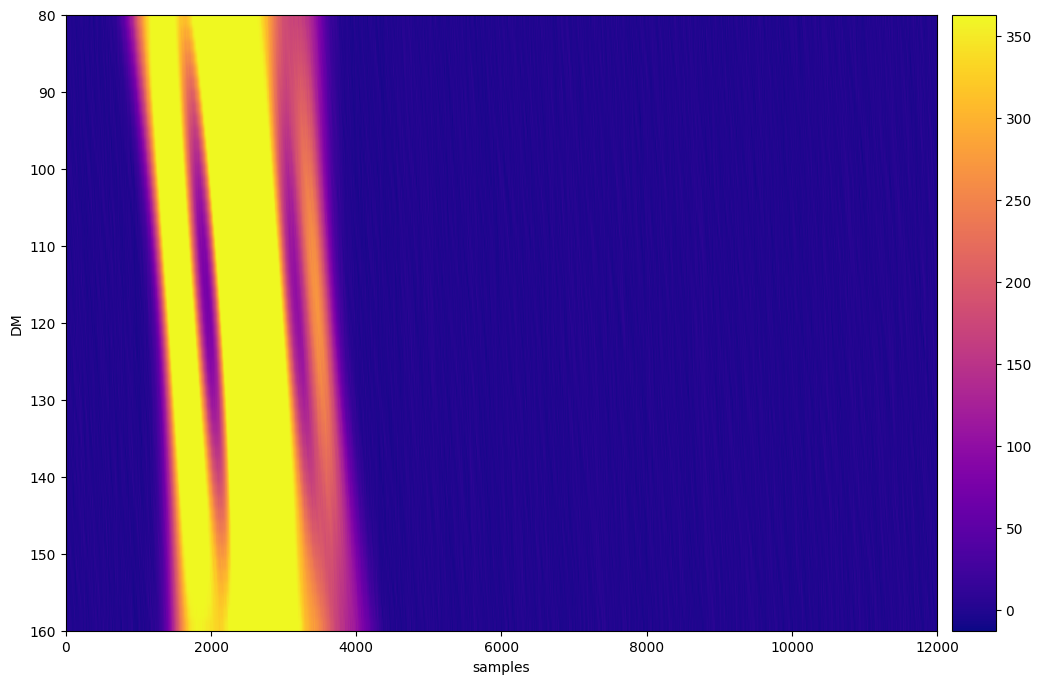

In [20]:
burst.bowtieplot(dminterval=(80, 160), badchannels=badchannels, backgroundrange=bkgrange);

Note that with a multi-peak burst like this, the bowtie may be blurred or hard to spot. With a log scale and the color range limited to just the higher values, the background is ignored and the plot is as follows:

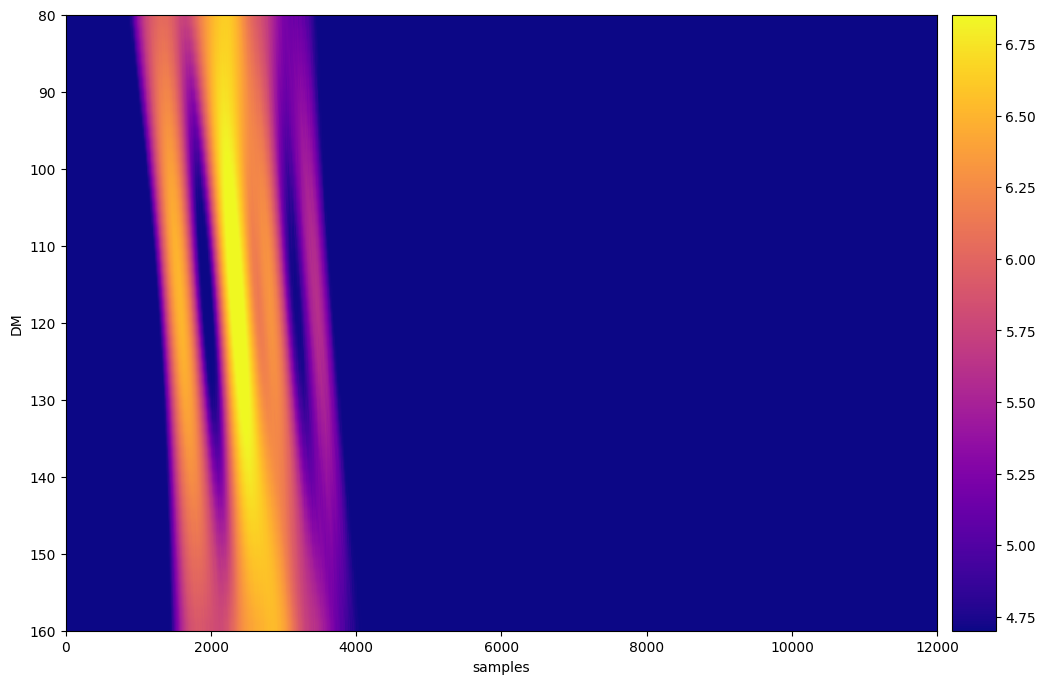

In [21]:
burst.bowtieplot(dminterval=(80, 160), badchannels=badchannels, backgroundrange=bkgrange, logscale=True, vmin=0.8, vmax=0.995);

If you want the actual bowtie data, a call to the `bowtie` method of the `Burst` object will give you that: it returns a tuple of the data (as a 2D NumPy array) and a list of DMs (as a 1D NumPy array). Here, we use a small DM range around the estimated DM of 123.45.

In [22]:
# increase the resolution of the DMs, by setting `ndm=150`
bowtie, dms = burst.bowtie(dminterval=(120, 125), badchannels=badchannels, backgroundrange=bkgrange, ndm=150)
dms

<Quantity [120.        , 120.03355705, 120.06711409, 120.10067114,
           120.13422819, 120.16778523, 120.20134228, 120.23489933,
           120.26845638, 120.30201342, 120.33557047, 120.36912752,
           120.40268456, 120.43624161, 120.46979866, 120.5033557 ,
           120.53691275, 120.5704698 , 120.60402685, 120.63758389,
           120.67114094, 120.70469799, 120.73825503, 120.77181208,
           120.80536913, 120.83892617, 120.87248322, 120.90604027,
           120.93959732, 120.97315436, 121.00671141, 121.04026846,
           121.0738255 , 121.10738255, 121.1409396 , 121.17449664,
           121.20805369, 121.24161074, 121.27516779, 121.30872483,
           121.34228188, 121.37583893, 121.40939597, 121.44295302,
           121.47651007, 121.51006711, 121.54362416, 121.57718121,
           121.61073826, 121.6442953 , 121.67785235, 121.7114094 ,
           121.74496644, 121.77852349, 121.81208054, 121.84563758,
           121.87919463, 121.91275168, 121.94630872, 121.97986

In [23]:
bowtie

array([[ -3.45988935,  31.2965115 ,  11.12846252, ...,  14.11288545,
         -0.20919907,   6.89187813],
       [  9.82242633,  32.21921216,  -6.99566067, ...,  15.13717832,
         -3.99801159,  11.27963589],
       [  7.72048731,  31.6529869 ,  -5.70499855, ...,  10.49366152,
         -4.11175669,  12.15213119],
       ...,
       [ 22.88145774,  -7.00940836,   6.9497835 , ...,   4.50944412,
         -0.03237134, -18.30677737],
       [ 20.11145947,   1.08576119,  -2.88149539, ...,  -8.47803963,
         -1.42737713, -10.58501003],
       [  6.51953945,   9.42832792, -13.36632921, ...,   2.36639123,
         -7.15900165,   2.30613099]], shape=(150, 12000))

# Structure optimization

The following uses the idea of optimizing (maximizing) the structure parameter to obtain a best-estimate value (and an uncertainty estimate) for the DM.
The implementation underlying this part follows Sutinjo et al. 2023, [10.3847/1538-4357/ace774](https://doi.org/10.3847/1538-4357/ace774)

1. Obtain the bow-tie data in a small DM range, as above
2. Create a `Structure` instance from the data and DM array

In [24]:
structure = Structure(bowtie, dms)
structure

Structure for data shaped (150, 12000), with DM interval from 120.0 pc / cm3 to 125.0 pc / cm3

3. Calculate the k_c parameter (this is automatically done in step 4 if the current step is skipped).

In [25]:
structure.calc_kc()

74

4. Estimate the actual structure, and an error range

In [26]:
optdm, lowdm, highdm, mindm, maxdm = structure.calc()

/Users/evert/projects/hessels2025/code/amsterdm/src/amsterdm/structure.py:182: UserWarning: minimum dm estimate is at the lower edge of the input dm range
  warnings.warn(
/Users/evert/projects/hessels2025/code/amsterdm/src/amsterdm/structure.py:186: UserWarning: minimum dm estimate is at the lower edge of the input dm range
  warnings.warn(


In [27]:
f"{optdm.value:.5f} {lowdm.value:+.5f}/{highdm.value:+.5f}  pc / cm3"

'123.42282 -3.42282/+1.57718  pc / cm3'

In [28]:
f"DM range = {mindm.value} – {maxdm.value}  pc / cm3"

'DM range = 120.0 – 125.0  pc / cm3'

The formatting above, and the use of <variable>.value, is used because all DM variables are AstroPy quantities, and outputting them normaly would produce a lot of repeated units.

The low and high variables are the actual lower and upper bound errors, while min and max refer to the range. Obviously, the range is limited by the input range. We can try again, with a larger range:

In [29]:
bowtie, dms = burst.bowtie(dminterval=(115, 130), badchannels=badchannels, backgroundrange=bkgrange, ndm=150)
structure = Structure(bowtie, dms)
structure.calc_kc()
structure.calc()

(<Quantity 123.55704698 pc / cm3>,
 <Quantity -5.53691275 pc / cm3>,
 <Quantity 5.33557047 pc / cm3>,
 <Quantity 118.02013423 pc / cm3>,
 <Quantity 128.89261745 pc / cm3>)

This time, all values fit within the input range. So the best estimate for DM is 123.56, but the errors are rather large.

For visualization, we can create various plots. Let's start with a spectrum plot, which will also indicate where the $k_c$ variable sits.

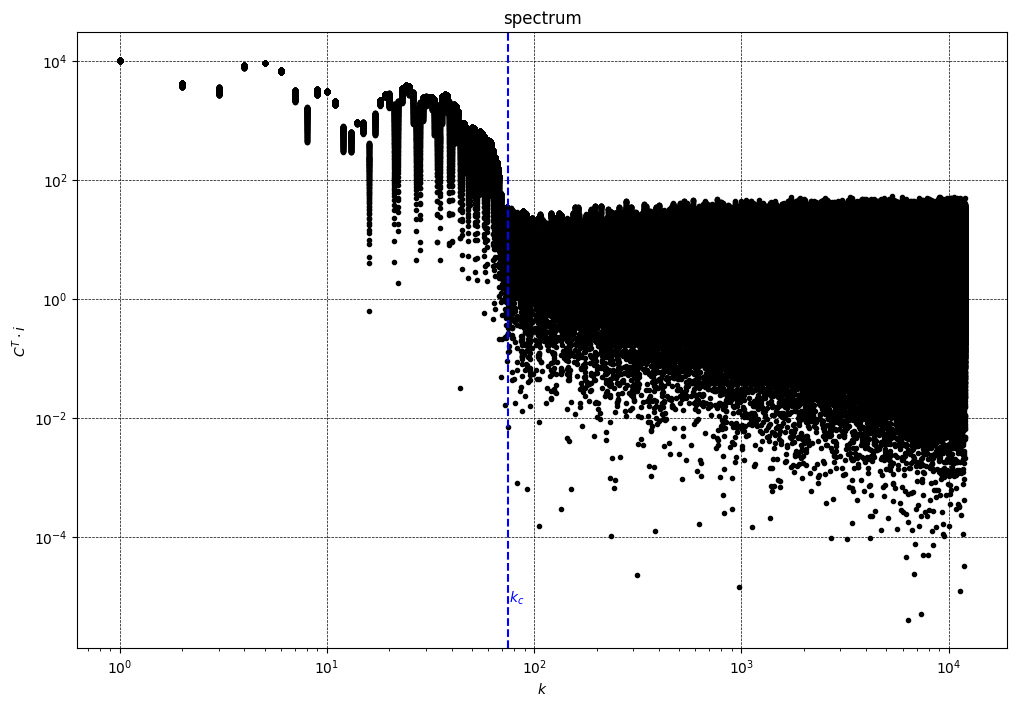

In [30]:
structure.plot_spectrum();

Next, we plot the structure parameter as function of the DM

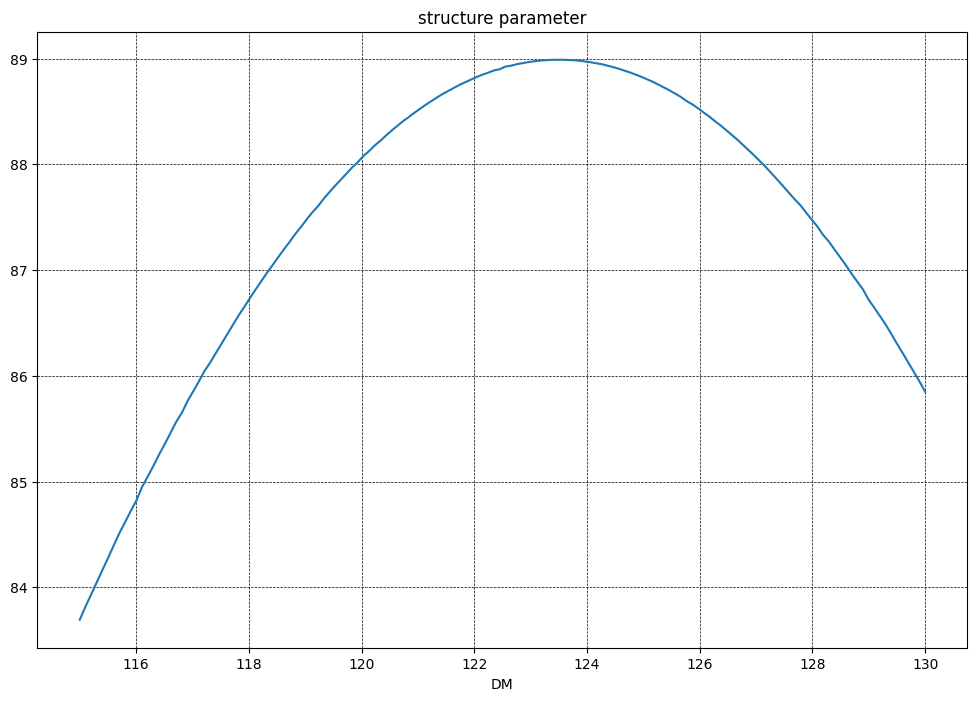

In [31]:
structure.plot_structure();

The adjusted structure parameter is the structure plus its error, whereby the error is relative to the error at `optmd`,  our best DM estimate (so the error is zero at that point).

This is used to determine the uncertainty range of DM, which takes the value of the structure value at the best DM, and then finds the DMs where the value drops below this (i.e., the intersection of the straight line at height of 89 with the left and right parts of the curve in the below figure).

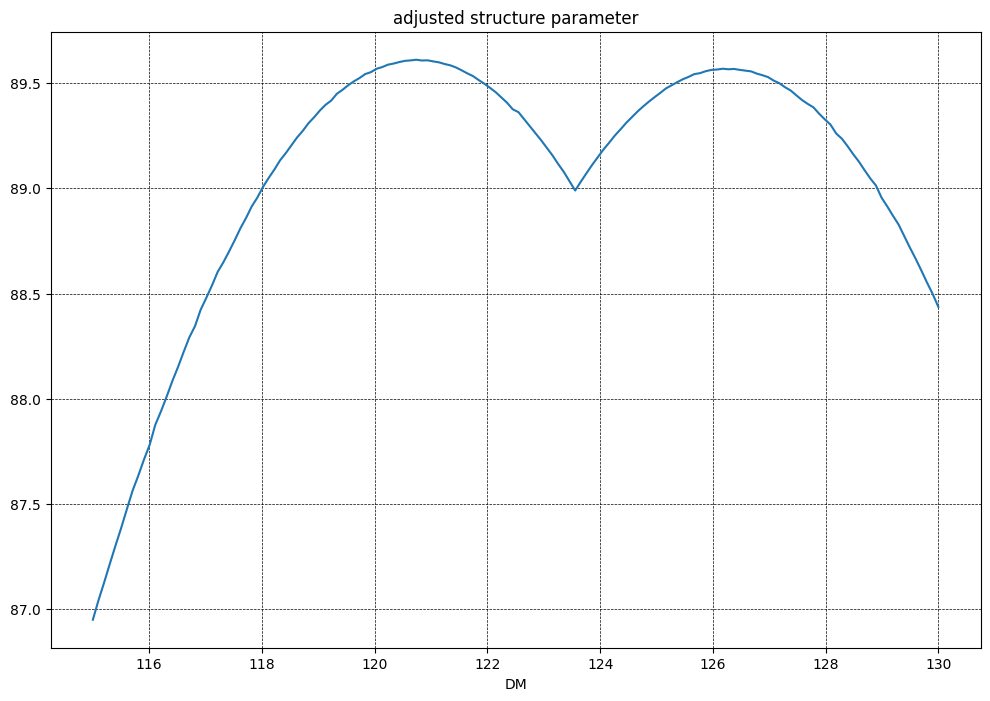

In [32]:
structure.plot_adjusted_structure();

We can also plot the uncertainty value itself:

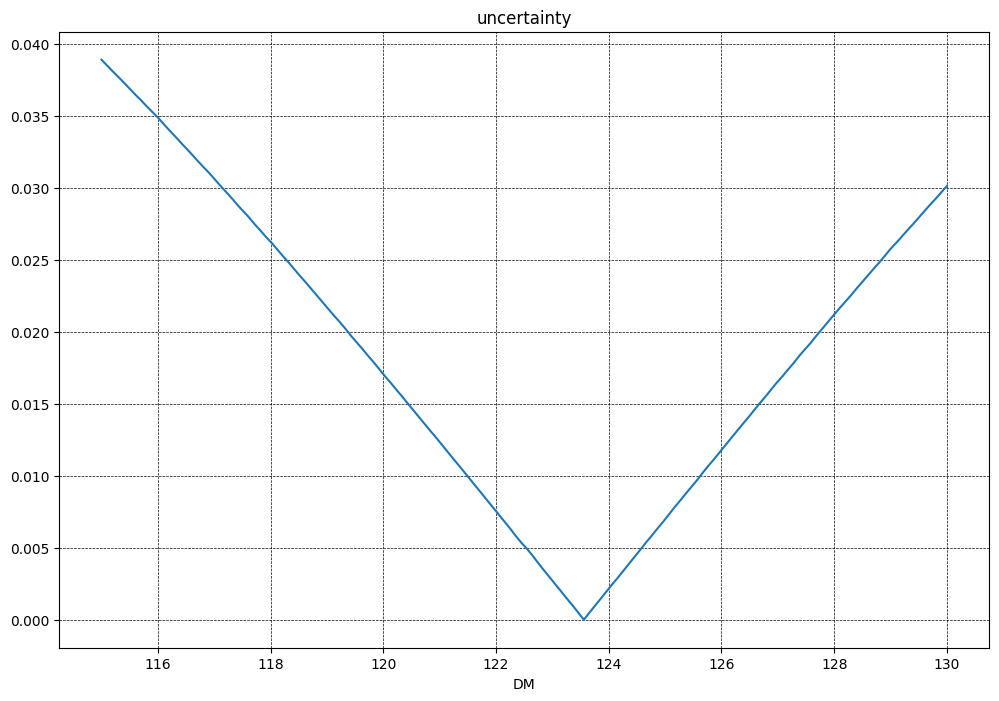

In [33]:
structure.plot_uncertainty();

Finally, we can plot the detrended noise (i.e., the data minus the smoothed data):

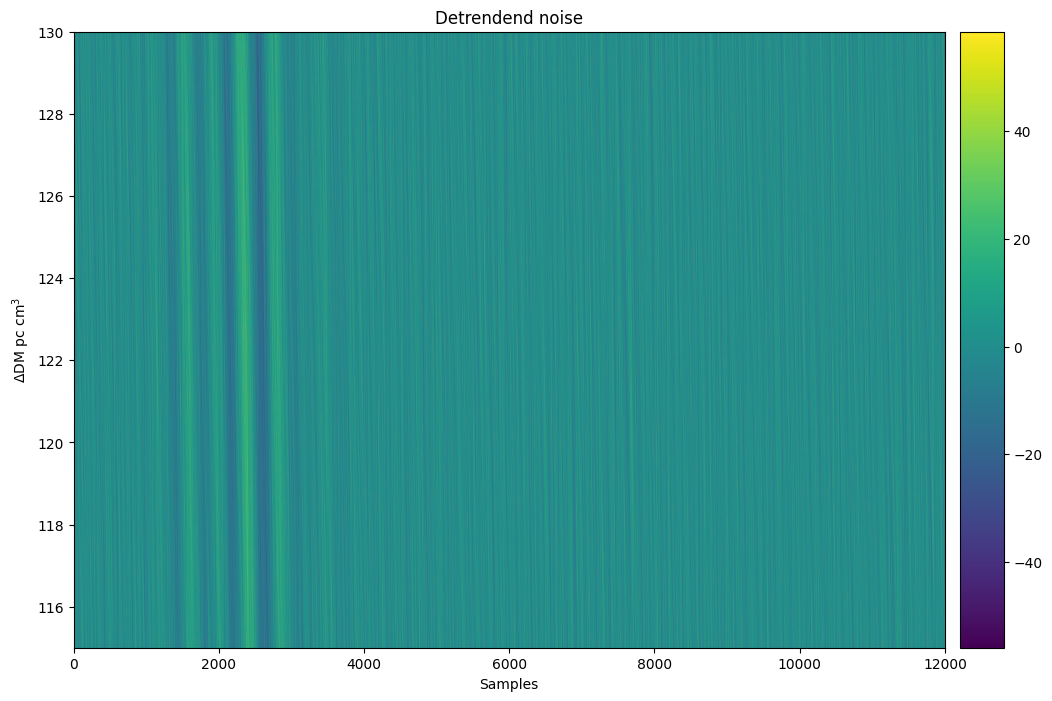

In [34]:
structure.plot_detrended_noise();

### Combining the plots

The plot methods take, among others, an `ax` argument, which can contain the Matplotlib axes instance to draw on. With that, we can create a figure mosaic:

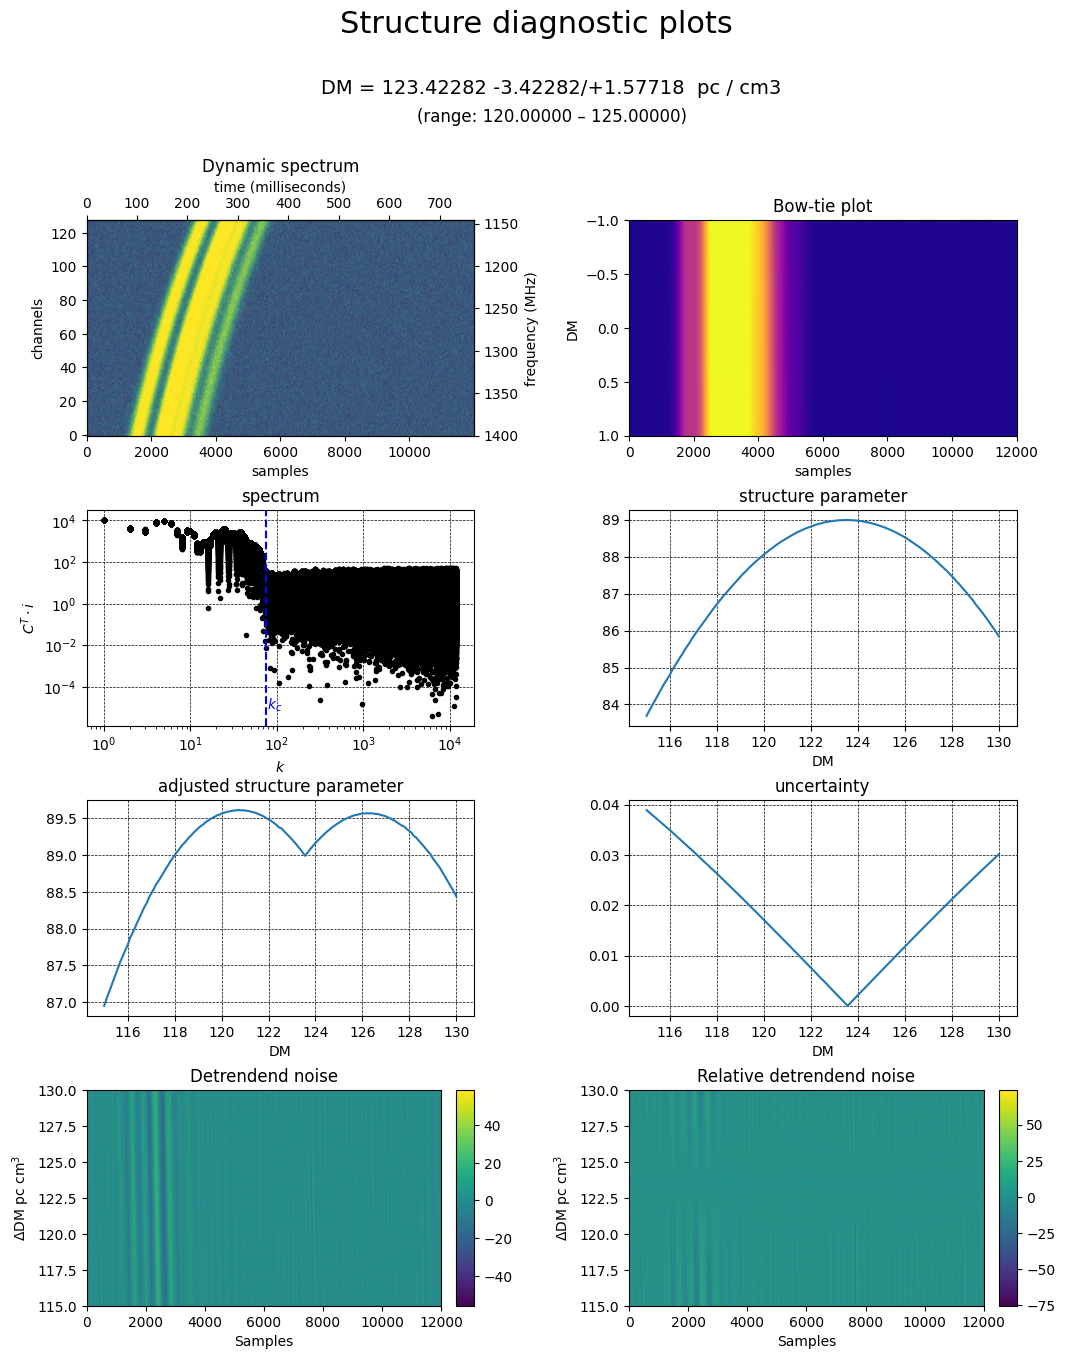

In [35]:
fig, ax = plt.subplot_mosaic(
    [
        ["results", "results"],
        ["waterfall", "bowtie"],
        ["spectrum", "structure"],
        ["adj_structure", "uncertainty"],
        ["detr_noise", "reldetr_noise"],
    ],
    height_ratios=[1, 3, 3, 3, 3],
    figsize=(12, 16),
)

text = f"DM = {optdm.value:.5f} {lowdm.value:+.5f}/{highdm.value:+.5f}  pc / cm3"
suptext = f"(range: {mindm.value:.5f} – {maxdm.value:.5f})"
ax["results"].text(
    x=0.5, y=0.8, s=text, va="center", ha="center", fontsize=14, color="black"
)
ax["results"].text(
    x=0.5, y=0.4, s=suptext, va="center", ha="center", fontsize=12, color="black"
)
ax["results"].set_axis_off()

burst.waterfall(backgroundrange=[0.5, 1], ax=ax["waterfall"], cbar=False)
ax["waterfall"].set_title("Dynamic spectrum")

burst.bowtieplot(
    dminterval=[-1, 1],
    backgroundrange=[0.5, 1],
    ndm=150,
    ax=ax["bowtie"],
    cbar=False,
)
ax["bowtie"].set_title("Bow-tie plot")

structure.plot_spectrum(ax=ax["spectrum"])
structure.plot_structure(ax=ax["structure"])
structure.plot_adjusted_structure(ax=ax["adj_structure"])
structure.plot_uncertainty(ax=ax["uncertainty"])
structure.plot_detrended_noise(ax=ax["detr_noise"])
structure.plot_relative_detrended_noise(ax=ax["reldetr_noise"])

fig.suptitle("Structure diagnostic plots", y=0.92, fontsize=22)

# Make some space for the axis labels
# Otherwise, the labels overlap between subplots
fig.subplots_adjust(wspace=0.4, hspace=0.4);